## 환경 호환성 패치

### SimpleNet metrics.py
- 문제: pandas 최신버전에서 df.append() 삭제됨
- 수정: pd.concat()으로 대체
- 파일: /content/SimpleNet/metrics.py

### PatchCore run_patchcore.py  
- 문제: torchvision 최신버전에서 transform_mean/std 속성 없음
- 수정: ImageNet 정규화 표준값으로 하드코딩
  - mean: [0.485, 0.456, 0.406]
  - std: [0.229, 0.224, 0.225]
- 파일: /content/patchcore-inspection/bin/run_patchcore.py

- 실행 환경: Google Colab, T4 GPU
- 실행 파일: method1/source/run_patchcore_simplenet.ipynb
- 주요 하이퍼파라미터: -p 0.1, WideResNet50, layer2+3, resize 256→crop 224

In [ ]:
!git clone https://github.com/amazon-research/patchcore-inspection.git
%cd patchcore-inspection
!pip install -r requirements.txt
!pip install -e .

Cloning into 'patchcore-inspection'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 365 (delta 13), reused 8 (delta 8), pack-reused 329 (from 1)
Receiving objects: 100% (365/365), 2.02 MiB | 18.81 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Filtering content: 100% (360/360), 2.14 GiB | 18.19 MiB/s, done.
/content/patchcore-inspection
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 14.8 MB/s eta 0:00:00
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=2c28d6c63863d253fe352e06351387e01859f6e6f82f77a58a838bd0f4a04897
  Stored in directory: /root/.cache/pip/wheels/4c/01/56/40a48f75dbdfe167a0cb70d3b48913369a00ec5c4e9fed5f2b
Successfully built pretrainedmodels
Obtaining file:///content/patchcore-insp

In [ ]:
%cd /content
!git clone https://github.com/DonaldRR/SimpleNet.git

/content
Cloning into 'SimpleNet'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 95 (delta 42), reused 31 (delta 31), pack-reused 39 (from 1)
Receiving objects: 100% (95/95), 235.91 KiB | 26.21 MiB/s, done.
Resolving deltas: 100% (47/47), done.


In [ ]:
!pip install faiss-cpu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/mvtec_data/archive.zip "hazelnut/*" -d /content/mvtec_data

Archive:  /content/drive/MyDrive/mvtec_data/archive.zip
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/000_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/001_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/002_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/003_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/004_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/005_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/006_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/007_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/008_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/009_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/010_mask.png  
  inflating: /content/mvtec_data/hazelnut/ground_truth/crack/011_mask.png  
  inflating: /content/mvtec_data

In [ ]:
with open('/content/SimpleNet/metrics.py', 'r') as f:
    content = f.read()

content = content.replace(
    'df = df.append({"pro": np.mean(pros), "fpr": fpr, "threshold": th}, ignore_index=True)',
    'df = pd.concat([df, pd.DataFrame([{"pro": np.mean(pros), "fpr": fpr, "threshold": th}])], ignore_index=True)'
)

with open('/content/SimpleNet/metrics.py', 'w') as f:
    f.write(content)

print("수정 완료!")

수정 완료!


In [ ]:
# 3. SimpleNet metrics.py 패치 (deprecated 코드 수정)
with open('/content/SimpleNet/metrics.py', 'r') as f:
    content = f.read()

content = content.replace(
    'df = df.append({"pro": np.mean(pros), "fpr": fpr, "threshold": th}, ignore_index=True)',
    'df = pd.concat([df, pd.DataFrame([{"pro": np.mean(pros), "fpr": fpr, "threshold": th}])], ignore_index=True)'
)

with open('/content/SimpleNet/metrics.py', 'w') as f:
    f.write(content)

print("SimpleNet metrics.py 수정 완료!")

In [ ]:
with open('/content/patchcore-inspection/bin/run_patchcore.py', 'r') as f:
    content = f.read()

content = content.replace(
    'dataloaders["testing"].dataset.transform_mean',
    '[0.485, 0.456, 0.406]'
)
content = content.replace(
    'dataloaders["testing"].dataset.transform_std',
    '[0.229, 0.224, 0.225]'
)

with open('/content/patchcore-inspection/bin/run_patchcore.py', 'w') as f:
    f.write(content)

print("수정 완료!")

수정 완료!


In [ ]:
%cd /content/patchcore-inspection
!python bin/run_patchcore.py \
    --gpu 0 \
    --seed 0 \
    results/mvtec_results \
    patch_core \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1024 \
    --target_embed_dimension 1024 \
    --anomaly_scorer_num_nn 1 \
    --patchsize 3 \
    sampler \
    -p 0.1 \
    approx_greedy_coreset \
    dataset \
    --resize 256 \
    --imagesize 224 \
    -d hazelnut \
    mvtec \
    /content/mvtec_data

/content/patchcore-inspection
INFO:__main__:Command line arguments: bin/run_patchcore.py --gpu 0 --seed 0 results/mvtec_results patch_core -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1024 --target_embed_dimension 1024 --anomaly_scorer_num_nn 1 --patchsize 3 sampler -p 0.1 approx_greedy_coreset dataset --resize 256 --imagesize 224 -d hazelnut mvtec /content/mvtec_data
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:__main__:Evaluating dataset [mvtec_hazelnut] (1/1)...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:20

In [ ]:
%cd /content/SimpleNet
!python main.py \
    --results_path results \
    --gpu 0 \
    dataset --subdatasets hazelnut mvtec /content/mvtec_data \
    net \
    -b wideresnet50 \
    -le layer2 -le layer3 \
    --meta_epochs 40 \
    --gan_epochs 4

/content/SimpleNet
2026-04-30 03:03:36.039591: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:__main__:Command line arguments: main.py --results_path results --gpu 0 dataset --subdatasets hazelnut mvtec /content/mvtec_data net -b wideresnet50 -le layer2 -le layer3 --meta_epochs 40 --gan_epochs 4
INFO:__main__:Dataset: train=391 test=110
INFO:__main__:Evaluating dataset [mvtec_hazelnut] (1/1)...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` 

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F
import sys
sys.path.append('/content/SimpleNet')
import simplenet
import backbones
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# PatchCore 메모리 뱅크 구성
backbone_pc = models.wide_resnet50_2(weights="IMAGENET1K_V1").to(device)
backbone_pc.eval()
features_layer2, features_layer3 = [], []

def hook2(m, i, o): features_layer2.append(o.detach())
def hook3(m, i, o): features_layer3.append(o.detach())

backbone_pc.layer2.register_forward_hook(hook2)
backbone_pc.layer3.register_forward_hook(hook3)

train_path = "/content/mvtec_data/hazelnut/train/good"
train_features = []
for img_name in sorted(os.listdir(train_path)):
    img = Image.open(os.path.join(train_path, img_name)).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    features_layer2.clear(); features_layer3.clear()
    with torch.no_grad():
        backbone_pc(img_tensor)
    f2 = F.adaptive_avg_pool2d(features_layer2[0], (28, 28))
    f3 = F.adaptive_avg_pool2d(features_layer3[0], (28, 28))
    feat = torch.cat([f2, f3], dim=1).squeeze(0)
    feat = feat.permute(1, 2, 0).reshape(-1, feat.shape[0])
    train_features.append(feat)
memory_bank = torch.cat(train_features, dim=0).cpu()
print(f"PatchCore 메모리 뱅크 완료: {memory_bank.shape}")

# SimpleNet 모델 로드
sn_model = simplenet.SimpleNet(device)
sn_model.load(
    backbone=backbones.load('wideresnet50'),
    layers_to_extract_from=['layer2', 'layer3'],
    device=device,
    input_shape=(3, 224, 224),
    pretrain_embed_dimension=1536,
    target_embed_dimension=1024,
    dsc_hidden=682,
)
ckpt = torch.load('/content/SimpleNet/results/project/group/test/models/0/mvtec_hazelnut/ckpt.pth', map_location=device)
sn_model.discriminator.load_state_dict(ckpt['discriminator'])
print("SimpleNet 모델 로드 완료!")

PatchCore 메모리 뱅크 완료: torch.Size([306544, 1536])


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1`. You can also use `weights=Wide_ResNet50_2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SimpleNet 모델 로드 완료!


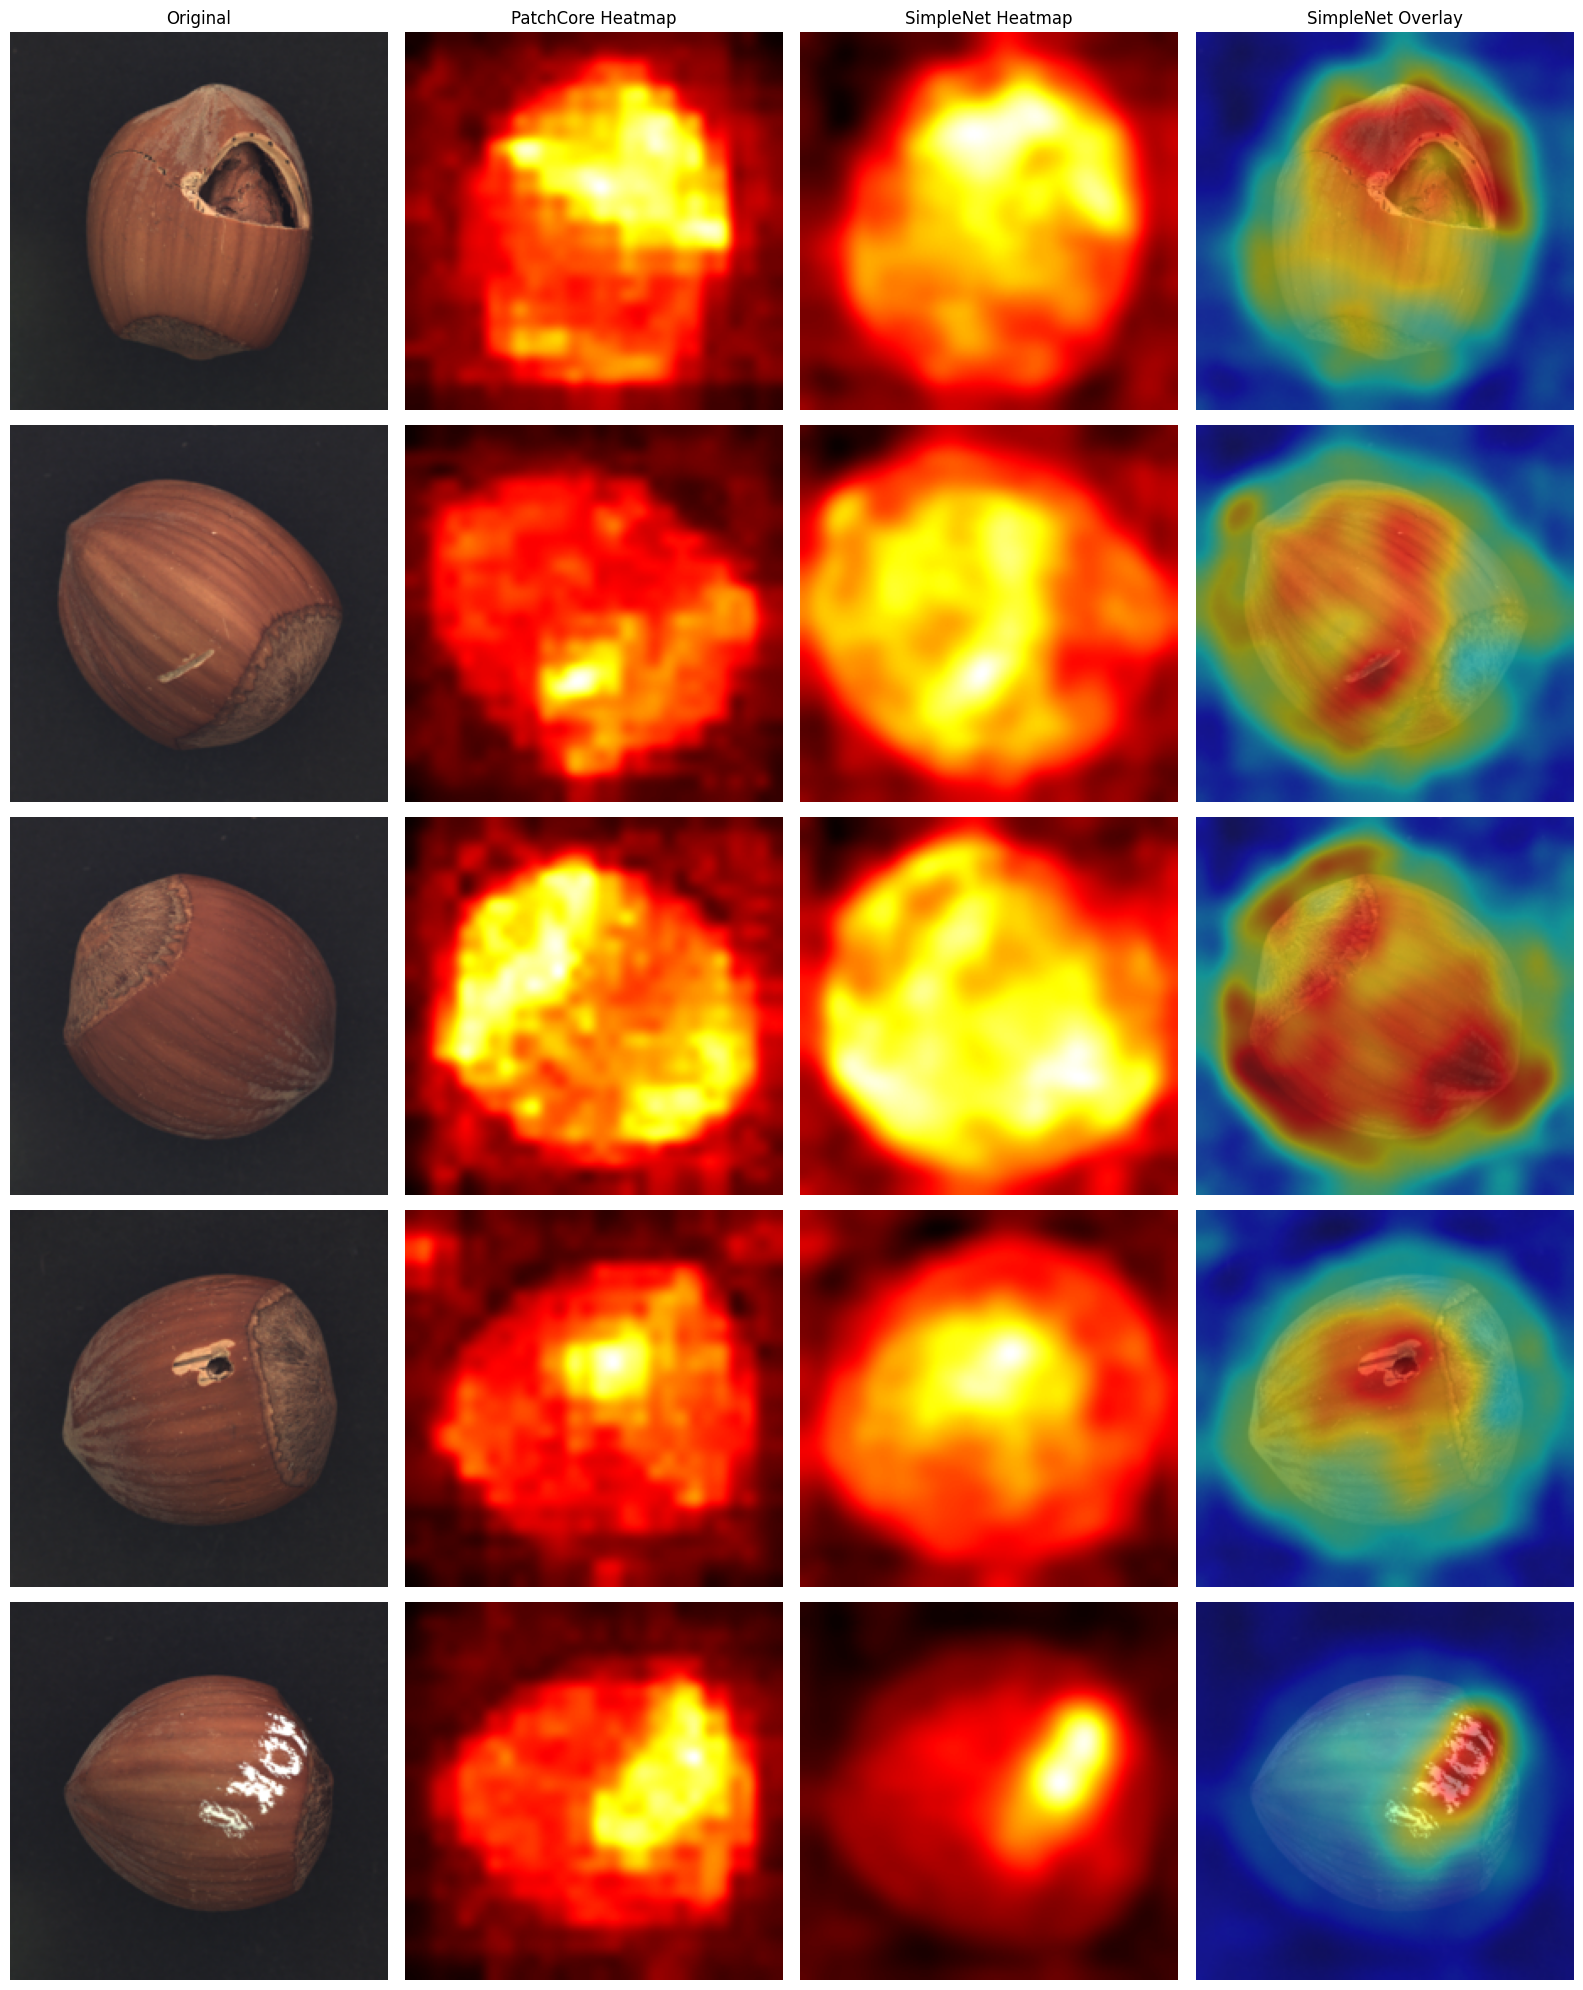

완료!


In [ ]:
test_base = "/content/mvtec_data/hazelnut/test"
defect_types = sorted([d for d in os.listdir(test_base) if os.path.isdir(os.path.join(test_base, d))])

fig, axes = plt.subplots(len(defect_types), 4, figsize=(16, 4*len(defect_types)))
cols = ['Original', 'PatchCore Heatmap', 'SimpleNet Heatmap', 'SimpleNet Overlay']
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=12)

for row, defect in enumerate(defect_types):
    defect_path = os.path.join(test_base, defect)
    img_path = os.path.join(defect_path, sorted(os.listdir(defect_path))[0])
    orig_img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_tensor = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

    # PatchCore 히트맵
    features_layer2.clear(); features_layer3.clear()
    with torch.no_grad():
        backbone_pc(img_tensor)
    f2 = F.adaptive_avg_pool2d(features_layer2[0], (28, 28))
    f3 = F.adaptive_avg_pool2d(features_layer3[0], (28, 28))
    feat = torch.cat([f2, f3], dim=1).squeeze(0)
    test_patches = feat.permute(1, 2, 0).reshape(-1, feat.shape[0]).cpu()
    dists = torch.cdist(test_patches, memory_bank)
    min_dists, _ = dists.min(dim=1)
    pc_map = min_dists.reshape(28, 28).numpy()
    pc_map = np.array(Image.fromarray(pc_map).resize((224, 224)))
    pc_map = (pc_map - pc_map.min()) / (pc_map.max() - pc_map.min() + 1e-8)

    # SimpleNet 히트맵
    _, sn_masks, _ = sn_model._predict(img_tensor)
    sn_map = np.array(sn_masks[0])
    sn_map = (sn_map - sn_map.min()) / (sn_map.max() - sn_map.min() + 1e-8)

    # 오버레이
    sn_color = cv2.applyColorMap((sn_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
    sn_color = cv2.cvtColor(sn_color, cv2.COLOR_BGR2RGB)
    overlay = (np.array(orig_img) * 0.5 + sn_color * 0.5).astype(np.uint8)

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_ylabel(defect, fontsize=10)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(pc_map, cmap='hot')
    axes[row, 1].axis("off")

    axes[row, 2].imshow(sn_map, cmap='hot')
    axes[row, 2].axis("off")

    axes[row, 3].imshow(overlay)
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig("comparison_hazelnut.png", dpi=150, bbox_inches="tight")
plt.show()
print("완료!")